## Estatística para Cientistas de Dados

**Objetivo**
Aplicar o exemplos apresentados no livro "Estatística Prática para cientistas de dados"

In [14]:
import pandas as pd

In [31]:
arquivo_csv = 'C:\\Users\\paula\\Documents\\Dev_projetos\\Desenvolvimento\\Myproject\\landing\\distribution-of-homicide-rates.csv'

In [32]:
pd.read_csv(arquivo_csv)

,country,Year,"Homicide rate per 100,000 population - sex: Total - age: Total"
0,Afghanistan,2009,4.071526
1,Afghanistan,2010,3.487093
2,Afghanistan,2011,4.208668
3,Afghanistan,2012,6.393912
4,Afghanistan,2015,9.975262
...,...,...,...
4707,Zimbabwe,2019,5.145035
4708,Zimbabwe,2020,4.977770
4709,Zimbabwe,2021,6.139985
4710,Zimbabwe,2022,6.654193


In [33]:
df = pd.read_csv(arquivo_csv)
df.head()

,country,Year,"Homicide rate per 100,000 population - sex: Total - age: Total"
0,Afghanistan,2009,4.071526
1,Afghanistan,2010,3.487093
2,Afghanistan,2011,4.208668
3,Afghanistan,2012,6.393912
4,Afghanistan,2015,9.975262


In [53]:
# Remove espaços em branco antes e depois de todos os nomes de colunas
df.columns = df.columns.str.strip()
df.head()


,country,Ano,homicide_rate
0,Afghanistan,2009,4.071526
1,Afghanistan,2010,3.487093
2,Afghanistan,2011,4.208668
3,Afghanistan,2012,6.393912
4,Afghanistan,2015,9.975262


In [56]:
#renomear colunas
df.rename(columns={
    'country':'País',
    'Year':'Ano',    
    'homicide_rate': 'Taxa_homicidios'
    }, inplace=True)

In [57]:
df.head()

,País,Ano,Taxa_homicidios
0,Afghanistan,2009,4.071526
1,Afghanistan,2010,3.487093
2,Afghanistan,2011,4.208668
3,Afghanistan,2012,6.393912
4,Afghanistan,2015,9.975262


In [69]:
print(df['Taxa_homicidios'].dtype)

float64


In [67]:
#Calcular a média da taxa de homicídios
media_taxa_homicidios = df['Taxa_homicidios'].mean()
print(f'Média da Taxa de Homicídios: {media_taxa_homicidios:.2f}')

Média da Taxa de Homicídios: 7.98


In [63]:
#Calcular a média aparada da taxa de homicídios
from scipy.stats import trim_mean

In [70]:
# Criar uma série sem os valores nulos
taxas_limpas = df['Taxa_homicidios'].dropna()

In [75]:
# Calculamos a média aparada sobre os dados limpos
proporcao_corte = 0.1  # 10% de corte nas extremidades
media_aparada = trim_mean(taxas_limpas, proporcao_corte)

print(f"Média Aparada: {media_aparada:.2f}")

Média Aparada: 5.28


In [68]:
#Calcular a mediana da taxa de homicídios
mediana_taxa_homicidios = df['Taxa_homicidios'].median()
print(f'Mediana da Taxa de Homicídios: {mediana_taxa_homicidios:.2f}')

Mediana da Taxa de Homicídios: 3.16


## O Diagnóstico dos Dados
**Dados positivamente assimétricos (ou com assimetria à direita)**

- A Mediana (3.16) nos diz que metade dos países do arquivo tem uma taxa de homicídios bem baixa, abaixo de 3.2.

- A Média (7.98) está sendo "puxada" para cima, quase o dobro da mediana.

- A Média Aparada (5.28) confirma que, quando você remove os extremos (os países extremamente violentos), a "realidade típica" cai drasticamente.

A Seguir, vamos encontrar os "culpados".


In [80]:
# Mostra os 5 países com as maiores taxa
print(df.nlargest(5, 'Taxa_homicidios')[['País', 'Taxa_homicidios']])

             País  Taxa_homicidios
1293  El Salvador       138.773970
1292  El Salvador       134.778660
1294  El Salvador       117.161224
1295  El Salvador       112.500550
1313  El Salvador       106.819600


In [81]:
# Quantos países estão ACIMA da média de 7.98?
acima_da_media = df[df['Taxa_homicidios'] > 7.98].shape[0]
total_paises = df.shape[0]

print(f"{acima_da_media} países de {total_paises} estão acima da média geral.")

1277 países de 4712 estão acima da média geral.


Os dados de El Salvador são impressionantes (chegando a 138 h/100k) e explicam perfeitamente por que sua média aparada caiu tanto! Com apenas cerca de 27% dos países (1277 de 4712) acima da média, fica claro que esses poucos valores extremos estão distorcendo toda a análise.

Vamos criar um gráfico: 

- A "Caixa" central: Representa onde estão 50% dos seus dados (o miolo). Como sua mediana é 3.16, a linha dentro da caixa estará bem à esquerda.

- Os "Bigodes" (whiskers): Mostram a dispersão dos dados "normais".

- Os Pontos (Outliers): Você verá uma longa linha de pontos que vai até o 138. São esses pontos que "puxam" a média simples para 7.98.

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

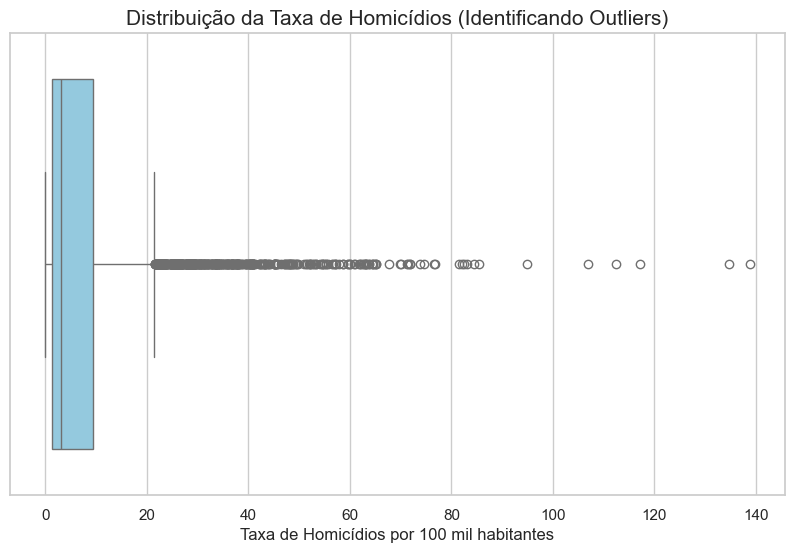

In [83]:
# Configurando o estilo do gráfico
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Criando o boxplot
sns.boxplot(x=df['Taxa_homicidios'], color='skyblue')

# Adicionando título e rótulos
plt.title('Distribuição da Taxa de Homicídios (Identificando Outliers)', fontsize=15)
plt.xlabel('Taxa de Homicídios por 100 mil habitantes', fontsize=12)

plt.show()

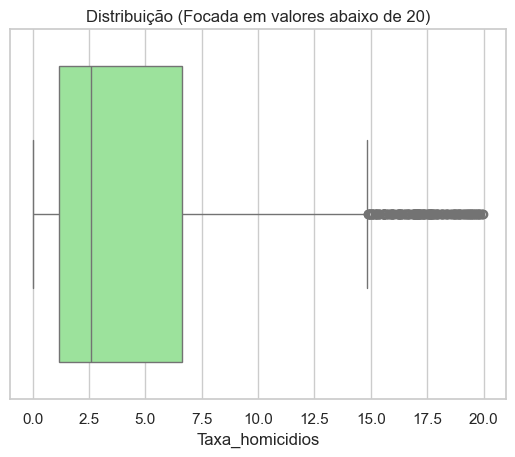

In [84]:
# Gráfico filtrado para ver melhor a concentração principal
sns.boxplot(x=df[df['Taxa_homicidios'] < 20]['Taxa_homicidios'], color='lightgreen')
plt.title('Distribuição (Focada em valores abaixo de 20)')
plt.show()

C:\Users\paula\AppData\Local\Temp\ipykernel_18780\2794937043.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


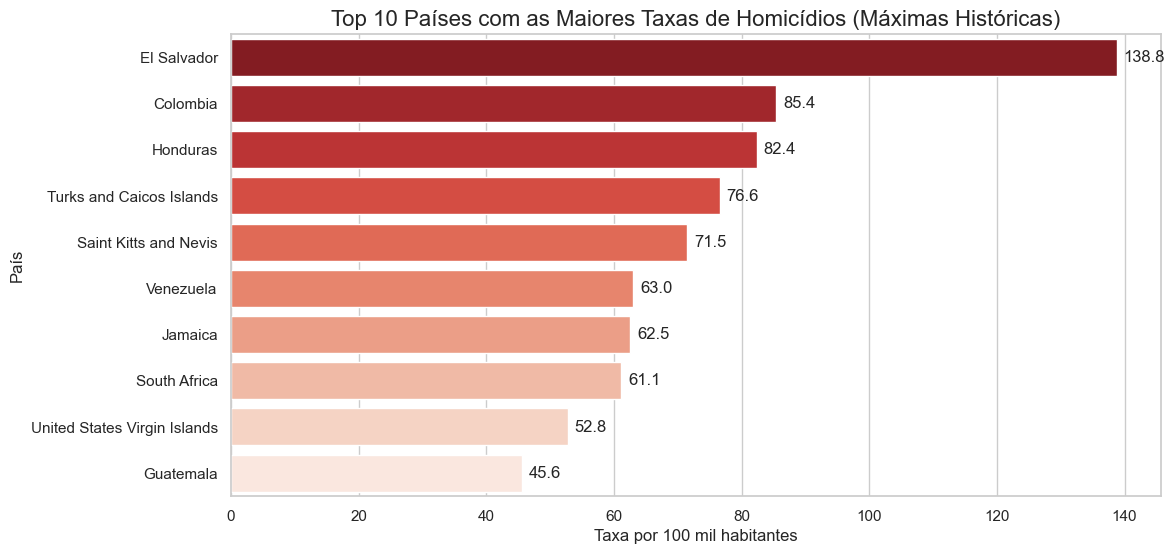

In [85]:
# 1. Agrupando por país para não repetir nomes (pegando a maior taxa histórica de cada um)
top_10 = df.groupby('País')['Taxa_homicidios'].max().sort_values(ascending=False).head(10).reset_index()

# 2. Configurando o visual
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Criando o gráfico
grafico = sns.barplot(
    data=top_10, 
    x='Taxa_homicidios', 
    y='País', 
    palette='Reds_r' # Gradiente de vermelho para destacar a gravidade
)

# 4. Adicionando os valores nas barras (para facilitar a leitura)
for i in grafico.containers:
    grafico.bar_label(i, fmt='%.1f', padding=5)

plt.title('Top 10 Países com as Maiores Taxas de Homicídios (Máximas Históricas)', fontsize=16)
plt.xlabel('Taxa por 100 mil habitantes', fontsize=12)
plt.ylabel('País', fontsize=12)

plt.show()

**Agora faremos uma análise considerando 2 países de cada continente. Da América do Sul, não poderia faltar o Brasil. Os demais países foram escolhidos manualmente, considerando aqueles que possuem dados mais consistentes no dataset.**

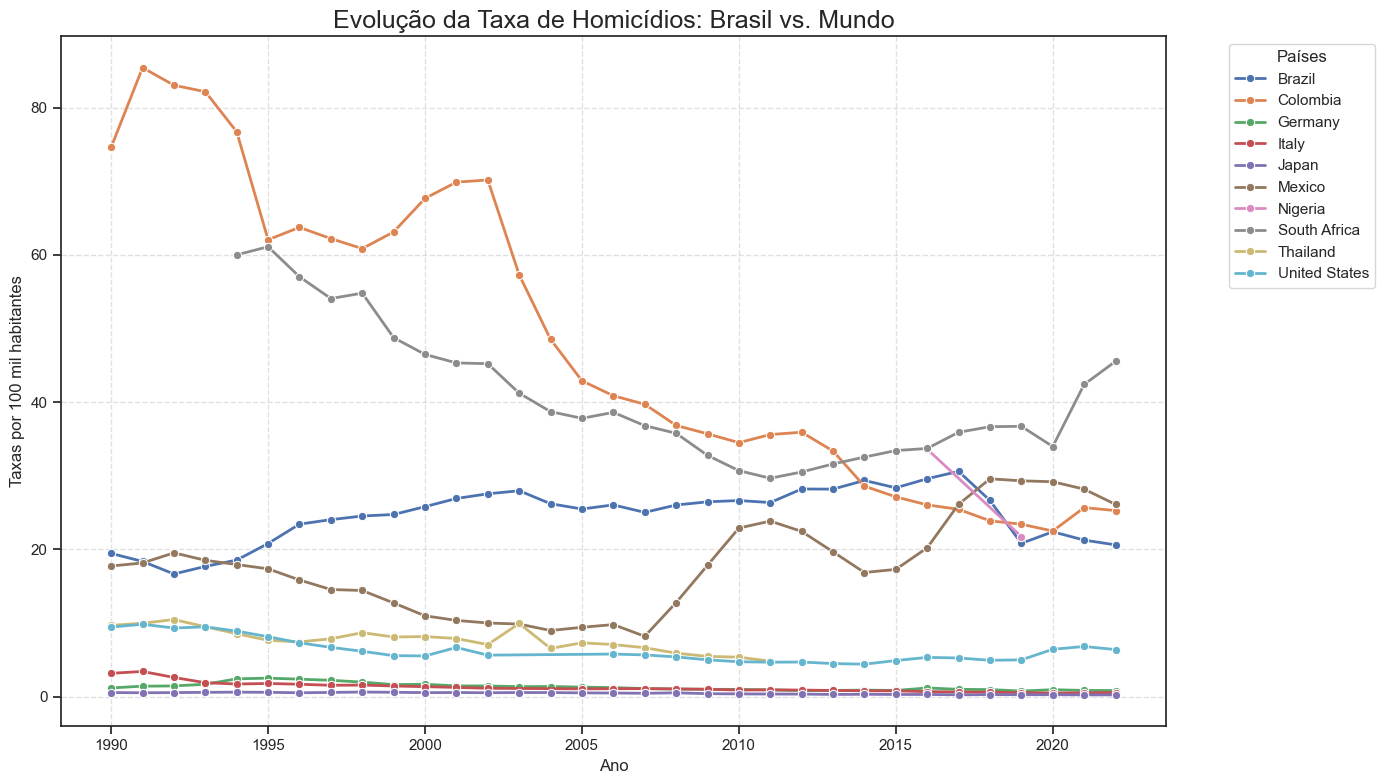

In [86]:
# 1. Definindo os países de cada continente (com Brasil na América do Sul)
paises_selecionados = [
    'Brazil', 'Colombia',               # América do Sul
    'United States', 'Mexico',          # América do Norte
    'Italy', 'Germany',                 # Europa
    'Japan', 'Thailand',                # Ásia
    'South Africa', 'Nigeria'           # África
]

# 2. Filtrando o DataFrame original
# Nota: os nomes estão em inglês no CSV
df_evolucao = df[df['País'].isin(paises_selecionados)]

# 3. Criando o gráfico de linhas
plt.figure(figsize=(14, 8))
sns.set_theme(style="ticks")

grafico_linha = sns.lineplot(
    data=df_evolucao, 
    x='Ano', 
    y='Taxa_homicidios', 
    hue='País', 
    marker='o',
    linewidth=2
)

# 4. Ajustes estéticos
plt.title('Evolução da Taxa de Homicídios: Brasil vs. Mundo', fontsize=18)
plt.ylabel('Taxas por 100 mil habitantes', fontsize=12)
plt.xlabel('Ano', fontsize=12)
plt.legend(title='Países', bbox_to_anchor=(1.05, 1), loc='upper left') # Legenda fora do gráfico
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Criando a coluna "Continente"**

In [88]:
import pycountry_convert as pc

def nome_para_continente(nome_pais):
    try:
        # 1. Converte nome do país para código de 2 letras (Ex: Brazil -> BR)
        codigo_pais = pc.country_name_to_country_alpha2(nome_pais)
        # 2. Converte código do país para código do continente (Ex: BR -> SA)
        codigo_continente = pc.country_alpha2_to_continent_code(codigo_pais)
        
        # 3. Dicionário para traduzir os códigos dos continentes
        mapa_continentes = {
            'AF': 'África', 'AS': 'Ásia', 'EU': 'Europa', 
            'NA': 'América do Norte', 'OC': 'Oceania', 'SA': 'América do Sul', 'AN': 'Antártida'
        }
        return mapa_continentes.get(codigo_continente)
    except:
        return "Outros" # Caso o nome não seja reconhecido

# Criando a nova coluna!
df['Continente'] = df['País'].apply(nome_para_continente)
df.head()

,País,Ano,Taxa_homicidios,Continente
0,Afghanistan,2009,4.071526,Ásia
1,Afghanistan,2010,3.487093,Ásia
2,Afghanistan,2011,4.208668,Ásia
3,Afghanistan,2012,6.393912,Ásia
4,Afghanistan,2015,9.975262,Ásia


C:\Users\paula\AppData\Local\Temp\ipykernel_18780\2136574208.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=media_continente, x='Taxa_homicidios', y='Continente', palette='viridis')


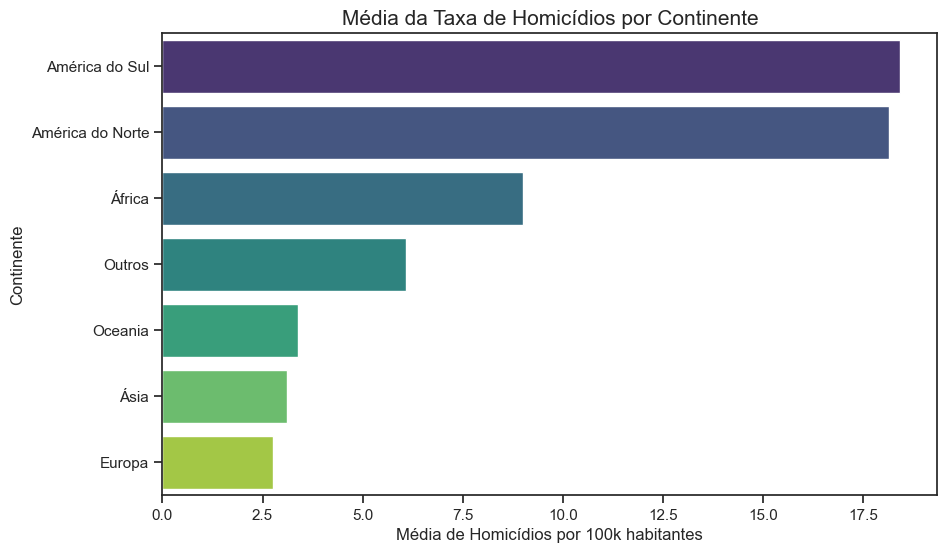

In [89]:
# Calculando a média por continente
media_continente = df.groupby('Continente')['Taxa_homicidios'].mean().sort_values(ascending=False).reset_index()

# Criando o gráfico de comparação
plt.figure(figsize=(10, 6))
sns.barplot(data=media_continente, x='Taxa_homicidios', y='Continente', palette='viridis')

plt.title('Média da Taxa de Homicídios por Continente', fontsize=15)
plt.xlabel('Média de Homicídios por 100k habitantes')
plt.show()

In [90]:
# Lista os nomes únicos que caíram em "Outros"
rebeldes = df[df['Continente'] == 'Outros']['País'].unique()
print(f"Países não identificados: {rebeldes}")

Países não identificados: ['Africa (UN)' 'Aland Islands' 'Americas (UN)' 'Asia (UN)'
 'Austria-Hungary' 'Bonaire Sint Eustatius and Saba' 'Cocos Islands'
 "Cote d'Ivoire" 'Curacao' 'Czechoslovakia' 'Democratic Republic of Congo'
 'Democratic Republic of Vietnam' 'Duchy of Modena and Reggio'
 'Duchy of Parma and Piacenza' 'East Germany' 'East Timor'
 'England and Wales' 'Ethiopia (former)' 'Europe (UN)'
 'Federal Republic of Central America' 'Grand Duchy of Baden'
 'Grand Duchy of Tuscany' 'Great Colombia' 'Kingdom of Bavaria'
 'Kingdom of Sardinia' 'Kingdom of Saxony' 'Kingdom of Wurttemberg'
 'Kingdom of the Two Sicilies' 'Korea (former)' 'Kosovo'
 'Latin America and the Caribbean (UN)' 'Melanesia' 'Micronesia (country)'
 'Netherlands Antilles' 'Northern Ireland' 'Oceania (UN)'
 'Orange Free State' 'Pakistan (former)' 'Pitcairn' 'Polynesia'
 'Republic of Vietnam' 'Reunion' 'Saint Barthelemy' 'Saint Helena'
 'Scotland' 'Serbia and Montenegro' 'Sint Maarten (Dutch part)' 'USSR'
 'Vatica

In [92]:
dicionario_rebeldes = {
    # Entidades Regionais/ONU (Mapeando direto para o continente)
    'Africa (UN)': 'Africa', 'Americas (UN)': 'Americas', 'Asia (UN)': 'Asia', 
    'Europe (UN)': 'Europe', 'Oceania (UN)': 'Oceania', 'World': 'World',
    'Latin America and the Caribbean (UN)': 'Americas',
    'Melanesia': 'Oceania', 'Polynesia': 'Oceania',
    
    # Países Modernos com nomes levemente diferentes ou territórios
    "Cote d'Ivoire": "Ivory Coast",
    'Democratic Republic of Congo': 'Congo, The Democratic Republic of the',
    'East Timor': 'Timor-Leste',
    'Micronesia (country)': 'Micronesia, Federated States of',
    'Vatican': 'Holy See (Vatican City State)',
    'Curacao': 'Curaçao',
    'Saint Barthelemy': 'Saint Barthélemy',
    'Sint Maarten (Dutch part)': 'Sint Maarten',
    'Bonaire Sint Eustatius and Saba': 'Bonaire, Sint Eustatius and Saba',
    'Reunion': 'Réunion',

    # Países Históricos (Aqui vamos mapear para o nome moderno mais próximo para o sistema achar o continente)
    'USSR': 'Russia',
    'Yugoslavia': 'Serbia',
    'Czechoslovakia': 'Czechia',
    'East Germany': 'Germany',
    'West Germany': 'Germany',
    'Serbia and Montenegro': 'Serbia',
    'Republic of Vietnam': 'Vietnam',
    'Democratic Republic of Vietnam': 'Vietnam',
    'Korea (former)': 'South Korea',
    'Ethiopia (former)': 'Ethiopia',
    'Pakistan (former)': 'Pakistan',
    
    # Reino Unido (A biblioteca às vezes se perde com as divisões)
    'England and Wales': 'United Kingdom',
    'Scotland': 'United Kingdom',
    'Northern Ireland': 'United Kingdom',

    # Antigas Cidades-Estado/Ducados (A maioria na Europa)
    'Austria-Hungary': 'Austria',
    'Duchy of Modena and Reggio': 'Italy',
    'Duchy of Parma and Piacenza': 'Italy',
    'Grand Duchy of Baden': 'Germany',
    'Grand Duchy of Tuscany': 'Italy',
    'Kingdom of Bavaria': 'Germany',
    'Kingdom of Sardinia': 'Italy',
    'Kingdom of Saxony': 'Germany',
    'Kingdom of Wurttemberg': 'Germany',
    'Kingdom of the Two Sicilies': 'Italy',
    'Great Colombia': 'Colombia',
    'Federal Republic of Central America': 'Guatemala'
}

# Aplicando a correção
df['País'] = df['País'].replace(dicionario_rebeldes)

# Rodando a função de continente novamente
df['Continente'] = df['País'].apply(nome_para_continente)

C:\Users\paula\AppData\Local\Temp\ipykernel_18780\3973887681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Continente', y='Taxa_homicidios', palette='Set2')


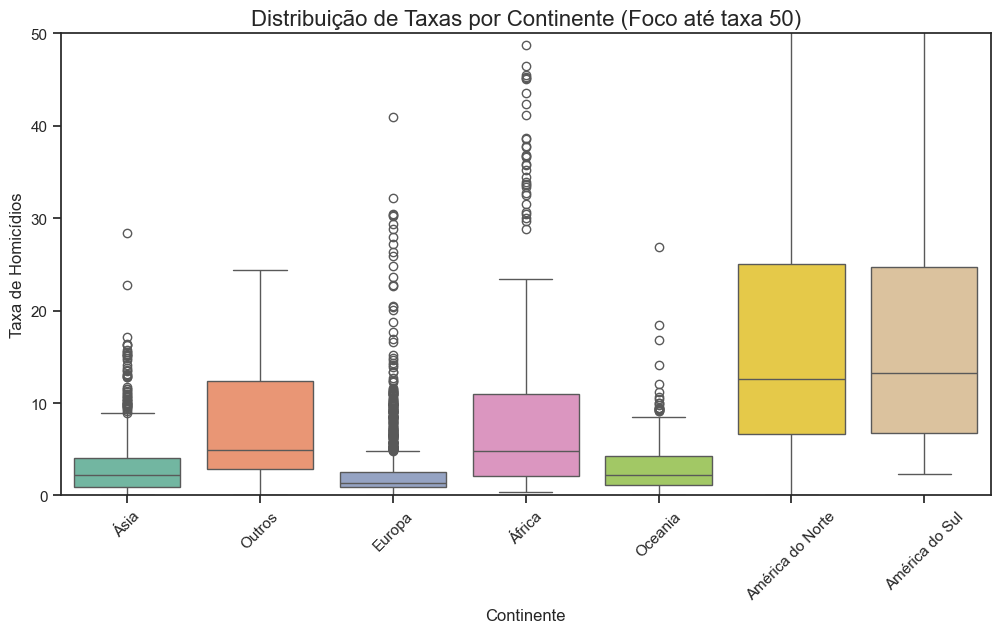

In [93]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Continente', y='Taxa_homicidios', palette='Set2')

# Como El Salvador (138) vai "esticar" muito o gráfico, 
# podemos limitar a visão para ver melhor as caixas
plt.ylim(0, 50) 

plt.title('Distribuição de Taxas por Continente (Foco até taxa 50)', fontsize=16)
plt.ylabel('Taxa de Homicídios')
plt.xticks(rotation=45)
plt.show()

In [95]:
#comando para salvar seu arquivo limpo
df.to_csv('Homicidios_Limpo_e_Traduzido.csv', index=False)
print("Arquivo salvo com sucesso!")

Arquivo salvo com sucesso!


**Análise para identificar qual continente teve a maior redução de violência nos últimos 20 anos**

In [96]:
# 1. Filtrando os anos de comparação
ano_inicial = 2000
ano_final = df['Ano'].max() # Pega o último ano disponível no seu dataset

df_2000 = df[df['Ano'] == ano_inicial].groupby('Continente')['Taxa_homicidios'].mean()
df_recente = df[df['Ano'] == ano_final].groupby('Continente')['Taxa_homicidios'].mean()

# 2. Criando um DataFrame de comparação
comparativo = pd.DataFrame({
    'Média 2000': df_2000,
    'Média Atual': df_recente
})

# 3. Calculando a variação percentual
comparativo['Variação %'] = ((comparativo['Média Atual'] - comparativo['Média 2000']) / comparativo['Média 2000']) * 100

# Ordenando pelos que mais reduziram a violência
comparativo = comparativo.sort_values('Variação %')

print(f"Comparativo entre {ano_inicial} e {ano_final}:")
print(comparativo)

Comparativo entre 2000 e 2023:
                  Média 2000  Média Atual  Variação %
Continente                                           
África             12.609248     1.704543  -86.481799
América do Sul     23.870004     4.318496  -81.908273
Ásia                3.345232     0.812571  -75.709573
Europa              3.557113     1.463498  -58.857139
América do Norte   14.349444    19.675646   37.117830
Oceania             2.846276          NaN         NaN
Outros              8.277472          NaN         NaN


C:\Users\paula\AppData\Local\Temp\ipykernel_18780\3699198602.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparativo['Variação %'], y=comparativo.index, palette=cores)


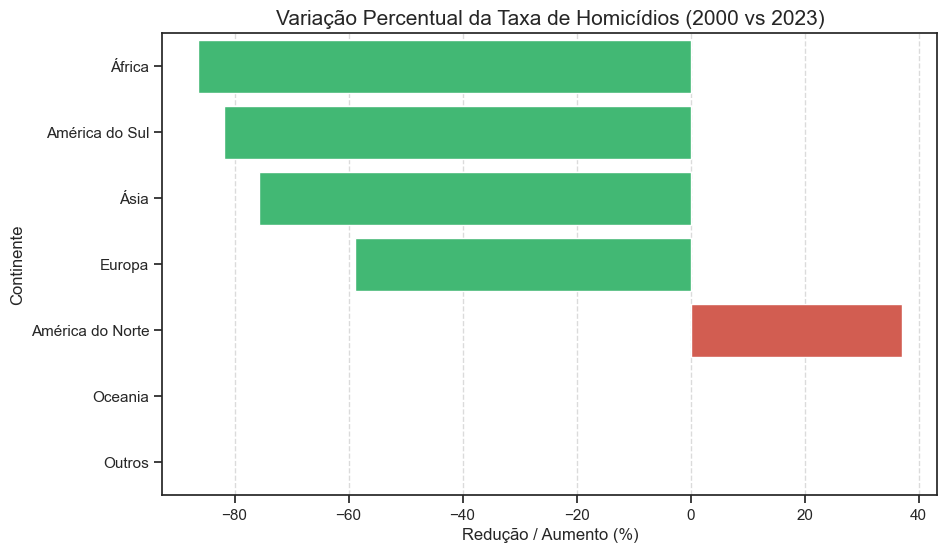

In [97]:
plt.figure(figsize=(10, 6))

# Cores: verde para redução, vermelho para aumento
cores = ['#2ecc71' if x < 0 else '#e74c3c' for x in comparativo['Variação %']]

sns.barplot(x=comparativo['Variação %'], y=comparativo.index, palette=cores)

plt.title(f'Variação Percentual da Taxa de Homicídios ({ano_inicial} vs {ano_final})', fontsize=15)
plt.xlabel('Redução / Aumento (%)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

**A primeira coisa que salta aos olhos é a queda drástica na África e na América do Sul (mais de 80%). Mas precisamos fazer uma ressalva importante antes de comemorar:**

1. O Alerta do "Viés de Sobrevivência"
Note que em 2000 a média da América do Sul era 23.87, mas em 2023 caiu para 4.31.

O que pode estar acontecendo: É muito provável que o seu arquivo de 2023 ainda não tenha os dados de todos os países (como Brasil, Colômbia ou Venezuela, que têm taxas altas).

Se o Pandas calculou a média de 2023 usando apenas 1 ou 2 países que já reportaram dados baixos, a média cai artificialmente.

2. O Caso da América do Norte (Aumento de 37%)
Diferente dos outros, a América do Norte subiu. Isso é um dado muito forte! Pode indicar que os países que já reportaram dados de 2023 (como possivelmente EUA ou México) estão enfrentando uma onda de violência maior do que tinham no ano 2000.

Vamos validar se os dados de 2023 estão completos!

In [98]:
contagem_paises = df[df['Ano'].isin([2000, 2023])].groupby(['Ano', 'Continente']).size().unstack()
print("Quantidade de países que reportaram dados:")
print(contagem_paises)

Quantidade de países que reportaram dados:
Continente  América do Norte  América do Sul  Europa  Oceania  Outros  África  \
Ano                                                                             
2000                      30               8      42        7      10       8   
2023                      41              16      64       24      13      57   

Continente  Ásia  
Ano               
2000          31  
2023          56  


In [99]:
#Ajustando o ano final para 2019
# 1. Filtrando os anos de comparação
ano_inicial = 2000
ano_final = 2019 # Pega o último ano disponível no seu dataset

df_2000 = df[df['Ano'] == ano_inicial].groupby('Continente')['Taxa_homicidios'].mean()
df_recente = df[df['Ano'] == ano_final].groupby('Continente')['Taxa_homicidios'].mean()

# 2. Criando um DataFrame de comparação
comparativo = pd.DataFrame({
    'Média 2000': df_2000,
    'Média Atual': df_recente
})

# 3. Calculando a variação percentual
comparativo['Variação %'] = ((comparativo['Média Atual'] - comparativo['Média 2000']) / comparativo['Média 2000']) * 100

# Ordenando pelos que mais reduziram a violência
comparativo = comparativo.sort_values('Variação %')

print(f"Comparativo entre {ano_inicial} e {ano_final}:")
print(comparativo)

Comparativo entre 2000 e 2019:
                  Média 2000  Média Atual  Variação %
Continente                                           
Europa              3.557113     1.534041  -56.873979
Ásia                3.345232     1.764288  -47.259622
América do Sul     23.870004    12.988356  -45.587124
Oceania             2.846276     1.559959  -45.192983
África             12.609248     7.963270  -36.845798
Outros              8.277472     6.665960  -19.468654
América do Norte   14.349444    19.191178   33.741612


Diferente de 2023, onde os dados estavam incompletos, aqui vemos uma tendência global de melhora, com uma exceção alarmante.

O Raio-X dos seus resultados:
O Sucesso Global: Europa, Ásia, América do Sul e Oceania tiveram reduções fortíssimas (perto de 50%). Isso mostra que, no geral, o mundo se tornou mais seguro nas últimas duas décadas.

O Mistério da América do Norte (+33.7%): Enquanto o resto do mundo melhorou, a América do Norte piorou significativamente. Isso se deve, em grande parte, ao aumento da violência no México (guerra do tráfico) e ao aumento gradual das taxas nos EUA nos últimos anos da década de 2010.

América do Sul (A maior queda em números absolutos): Embora a queda percentual seja similar à da Ásia, em números reais ela é gigante: saímos de uma média de 23.8 para 12.9. É uma vitória enorme, embora ainda estejamos muito longe dos níveis europeus (1.5)

O Brasil é um dos maiores países da América do Sul. Será que ele acompanhou essa queda de 45% do continente ou ele está "segurando" a média lá em cima?

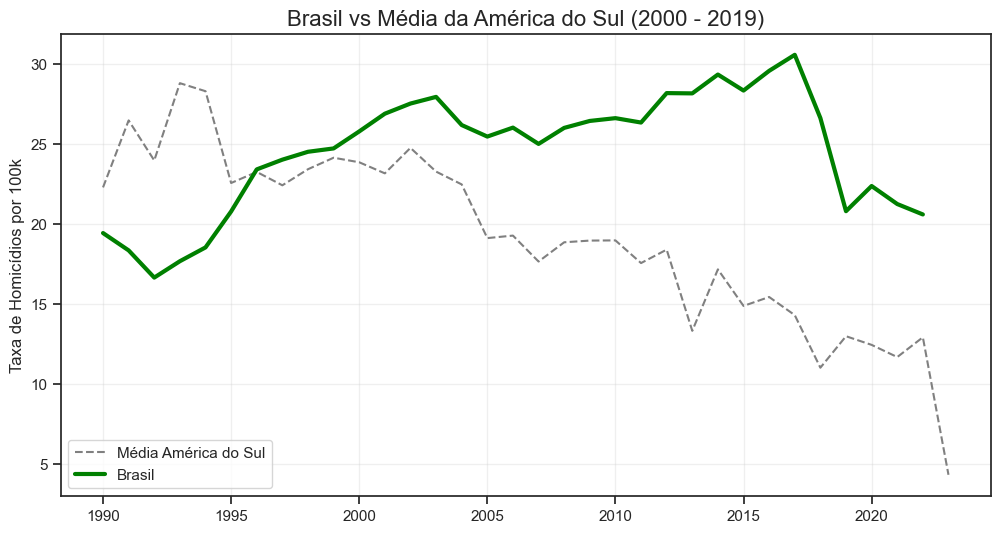

In [100]:
# 1. Calculando a média anual da América do Sul
media_sul = df[df['Continente'] == 'América do Sul'].groupby('Ano')['Taxa_homicidios'].mean()

# 2. Filtrando os dados do Brasil
brasil = df[df['País'] == 'Brazil'].set_index('Ano')['Taxa_homicidios']

# 3. Plotando a comparação
plt.figure(figsize=(12, 6))
plt.plot(media_sul.index, media_sul.values, label='Média América do Sul', color='gray', linestyle='--')
plt.plot(brasil.index, brasil.values, label='Brasil', color='green', linewidth=3)

plt.title('Brasil vs Média da América do Sul (2000 - 2019)', fontsize=16)
plt.ylabel('Taxa de Homicídios por 100k')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Exportando o relatório final

In [103]:
# 1. Criando o arquivo Excel com duas abas
with pd.ExcelWriter('Relatorio_Homicidios_Final.xlsx') as writer:
    # Aba 1: Todos os dados limpos e com continentes
    df.to_excel(writer, sheet_name='Dados_Completos', index=False)
    
    # Aba 2: O resumo comparativo (2000 vs 2019)
    comparativo.to_excel(writer, sheet_name='Resumo_Continentes')

print("Relatório 'Relatorio_Homicidios_Final.xlsx' gerado com sucesso!")

Relatório 'Relatorio_Homicidios_Final.xlsx' gerado com sucesso!


In [104]:
import os

arquivo = 'Relatorio_Homicidios_Final.xlsx'

if os.path.exists(arquivo):
    tamanho = os.path.getsize(arquivo) / 1024  # Tamanho em KB
    print(f"✅ Sucesso! O arquivo '{arquivo}' foi gerado.")
    print(f"📊 Tamanho do arquivo: {tamanho:.2f} KB")
else:
    print("❌ O arquivo ainda não foi encontrado na pasta.")

✅ Sucesso! O arquivo 'Relatorio_Homicidios_Final.xlsx' foi gerado.
📊 Tamanho do arquivo: 113.93 KB


## Minha evolução: 

**Percorri todo o ciclo de um cientista de dados:** 

- Debuguei erros de caminho de arquivo (FileNotFoundError).

- Limpei nomes de colunas complexas.

- Tratei valores nulos (NaN) para não quebrar cálculos.

- Criei novas informações (coluna de Continentes) a partir de dados brutos.

- Analisei a história dos dados através de Médias Aparadas, Boxplots e Gráficos de Evolução.

Uma última curiosidade:
Como a linha do Brasil está caindo, posso futuramente tentar correlacionar isso com outros dados, como o aumento da escolaridade ou a redução da pobreza no mesmo período. Os dados sempre abrem portas para novas perguntas!